# Causal Uncertainty & Computational Psychiatry
### Information Theory, Predictive Coding, and Auditory Hallucinations

---

This notebook models the ideas presented in **"Manipulating Causal Uncertainty in Sound Objects"** (Boger et al., 2021) through the lens of **Computational Psychiatry** and **Information Theory**.

### The Core Idea
When we hear a sound, we try to infer its cause. Boger et al. present a method to artificially increase a sound's *causal uncertainty* ($H_{cu}$) by altering its acoustic properties (pitch, speed, reverb, filters) until a neural network (YAMNet) becomes highly uncertain about its classification, maximizing the entropy of the output distribution.

In computational psychiatry, Karl Friston's **Free Energy Principle** (and Predictive Coding) posits that perception is Bayesian inference:
$$ Posterior (Percept) \propto Likelihood (Sensory Evidence) \times Prior (Expectations) $$

What happens when we feed a sound with high $H_{cu}$ (flat, ambiguous likelihood) into different psychiatric models?
1. **Neurotypical:** Remains uncertain.
2. **Schizophrenia:** An overly precise (maladaptive) prior dominates the ambiguous sensory input, leading the brain to confidently infer a cause that isn't there (a **hallucination**).
3. **Autism Spectrum:** Sensory evidence is weighted with unusually high precision, leading to a failure to contextualize noise using prior knowledge (sensory overload).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as stats

plt.style.use('default')
plt.rcParams.update({'axes.facecolor': 'white', 'figure.facecolor': 'white'})

## 1. Information Theory: Causal Uncertainty ($H_{cu}$)
We define causal uncertainty as the Shannon Entropy of the posterior over causes $C$ given sound $S$:
$$H(C|S) = -\sum P(c|s) \log P(c|s)$$

Boger et al. optimize sound parameters $\theta$ to maximize $H_{cu}$ while preserving the true label. Mathematically, they flatten the likelihood function.

Entropy (Clear): 0.65 bits
Entropy (Ambiguous): 2.23 bits


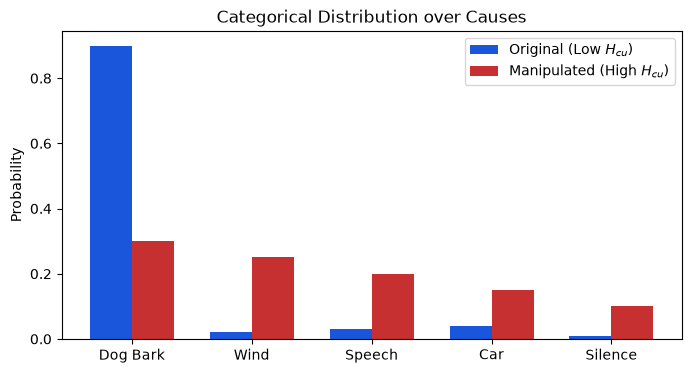

In [2]:
def entropy(p):
    return -np.sum(p * np.log2(p + 1e-12))

# Simulating YAMNet logits
classes = ['Dog Bark', 'Wind', 'Speech', 'Car', 'Silence']
x = np.arange(len(classes))

# Low H_cu (Clear sound)
p_low = np.array([0.9, 0.02, 0.03, 0.04, 0.01])
# High H_cu (Manipulated sound)
p_high = np.array([0.3, 0.25, 0.2, 0.15, 0.1])

print(f"Entropy (Clear): {entropy(p_low):.2f} bits")
print(f"Entropy (Ambiguous): {entropy(p_high):.2f} bits")

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
ax.bar(x - width/2, p_low, width, label='Original (Low $H_{cu}$)', color='#1a56db')
ax.bar(x + width/2, p_high, width, label='Manipulated (High $H_{cu}$)', color='#c73030')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Probability")
ax.set_title("Categorical Distribution over Causes")
ax.legend()
plt.show()

## 2. Predictive Coding & Psychiatric Models
Now we model perception as a 1D Gaussian belief updating process. Precision $\pi = 1/\sigma^2$.
$$ \mu_{\text{post}} = \frac{\pi_{lik}\mu_{lik} + \pi_{prior}\mu_{\text{prior}}}{\pi_{lik} + \pi_{prior}} $$
$$ \pi_{post} = \pi_{lik} + \pi_{prior} $$


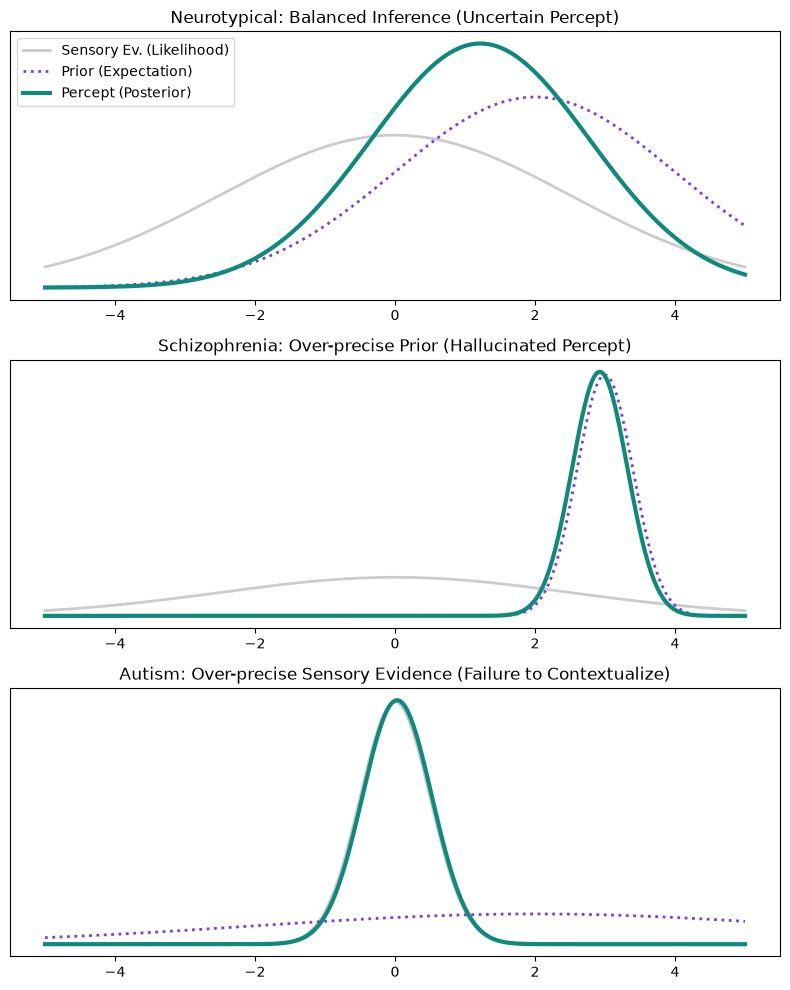

In [3]:
def bayesian_update(mu_lik, std_lik, mu_prior, std_prior):
    pi_lik = 1 / std_lik**2
    pi_prior = 1 / std_prior**2
    pi_post = pi_lik + pi_prior
    mu_post = (pi_lik * mu_lik + pi_prior * mu_prior) / pi_post
    std_post = np.sqrt(1 / pi_post)
    return mu_post, std_post

x_domain = np.linspace(-5, 5, 500)

def plot_inference(ax, mu_lik, std_lik, mu_prior, std_prior, title):
    mu_post, std_post = bayesian_update(mu_lik, std_lik, mu_prior, std_prior)
    
    ax.plot(x_domain, norm.pdf(x_domain, mu_lik, std_lik), color='#cccccc', lw=2, label='Sensory Ev. (Likelihood)')
    ax.plot(x_domain, norm.pdf(x_domain, mu_prior, std_prior), color='#7c3aed', lw=2, linestyle=':', label='Prior (Expectation)')
    ax.plot(x_domain, norm.pdf(x_domain, mu_post, std_post), color='#0e8a7d', lw=3, label='Percept (Posterior)')
    ax.set_title(title)
    ax.set_yticks([])

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# 1. Neurotypical (Balanced)
# Input is ambiguous (std_lik = 2.5), Prior is moderate (std_prior = 2.0)
plot_inference(axes[0], 0, 2.5, 2, 2.0, "Neurotypical: Balanced Inference (Uncertain Percept)")
axes[0].legend(loc='upper left')

# 2. Schizophrenia (Hallucination)
# Input is ambiguous, but Prior is excessively precise (std_prior = 0.4)
plot_inference(axes[1], 0, 2.5, 3, 0.4, "Schizophrenia: Over-precise Prior (Hallucinated Percept)")

# 3. Autism (Sensory Overload)
# Input precision is abnormally high (std_lik = 0.5), overwhelming the prior
plot_inference(axes[2], 0, 0.5, 2, 4.0, "Autism: Over-precise Sensory Evidence (Failure to Contextualize)")

plt.tight_layout()
plt.show()

### Summary
By algorithmically flattening the sensory likelihood (optimizing $H_{cu}$), we can simulate the environmental conditions that trigger psychiatric symptoms in computational models. An agent with a hallucination-prone architecture will reliably generate false percepts when subjected to high-$H_{cu}$ audio, as the Free Energy Principle forces the brain to "explain away" the ambiguity using its internal models.